In [63]:
import torch
import time
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA
import numpy as np

import sys
sys.path.append('./FLOCAT-GENAGN/What-if-Flocat-were-truly-generic-and-agnostic')
from flocat import flocatTrainer, flocat
import evaluation as ev

%load_ext autoreload
%autoreload 2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


device(type='cuda')

# Images

In [91]:
def load_embeddings(path):
    return torch.load(path, map_location="cpu")

inlier_topic = "grid"

data_train = load_embeddings(f"/home/2017025/ayouce01/FLOCAT-GENAGN/What-if-Flocat-were-truly-generic-and-agnostic/data/embeddings/wide_resnet50_2/{inlier_topic}/train.pt")
X_train = data_train["embeddings"]          

data_test = load_embeddings(f"/home/2017025/ayouce01/FLOCAT-GENAGN/What-if-Flocat-were-truly-generic-and-agnostic/data/embeddings/wide_resnet50_2/{inlier_topic}/test.pt")
X_test = data_test["embeddings"]
y_test = data_test["labels"]

/tmp/ipykernel_1521483/265150783.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(path, map_location="cpu")


In [ ]:
batch_size = 16
num_patches = X_train.shape[1]
attentions_train_mask = torch.ones((X_train.shape[0], num_patches), dtype=torch.long)
attentions_test_mask = torch.ones((X_test.shape[0], num_patches), dtype=torch.long)

flocat_config = {
    "latent_dim": X_train.shape[-1], "hidden_dim": 64, "depth": 2, "n_heads": 2,
    "freq_embed_size": 128, "lr": 1e-3, "weight_decay": 1e-4, "lambda_love": 1e-2,
    "epochs": 300, "lr_epochs": 150, "batch_size": batch_size,
    "coef_var": 1e-3, "target": "gaussian-neigh", "source": X_train,
    "attentions_mask": attentions_train_mask, "device": device,
}
flow_model = flocat(
    latent_dim=flocat_config["latent_dim"],
    hidden_dim=flocat_config["hidden_dim"],
    depth=flocat_config["depth"],
    n_heads=flocat_config["n_heads"],
).to(device)
flocatformer = flocatTrainer(flow_model, flocat_config)

t0 = time.time()
flocatformer.train(True)
t1 = time.time()
auc, fpr, ap = flocatformer.test(
    X_test, y_test, attentions_test_mask, type="norm-centroid", n_steps=10,
)
print(f"FLOCAT-GENAGN --> AUC: {auc:.4f} | FPR@95: {fpr:.4f} | AP: {ap:.4f}\n")


Epoch 1/300
Train Loss: 6.7368, LR: 0.000007
tensor(1.2214, device='cuda:0', grad_fn=<ExpBackward0>)

Epoch 101/300
Train Loss: 0.2354, LR: 0.000669
tensor(1.2214, device='cuda:0', grad_fn=<ExpBackward0>)

Epoch 201/300
Train Loss: 0.1316, LR: 0.000750
tensor(1.2213, device='cuda:0', grad_fn=<ExpBackward0>)
AUC:        0.5798
Avg Precision: 0.7992
FPR@95:     0.9048
FLOCAT-GENAGN --> AUC: 0.5798 | FPR@95: 0.9048 | AP: 0.7992



In [93]:
n_steps = 6
all_x_final, all_velocities, all_x_inter = flocatformer.euler_integrate(
    X_test.to(device),
    attentions_test_mask.to(device),
    n_steps, True
)

metrics_inter = {}
for i,x_temp in enumerate(all_x_inter):

    centroid_np = flocatformer.centroid.cpu().numpy() 
    scores = np.sum(
        (x_temp.cpu().numpy() - centroid_np) ** 2, axis=1
    )
    auc, fpr, ap = ev.evaluation(y_test, scores, False)
    metrics_inter[i] = (auc.round(4), fpr.round(4), ap.round(4))


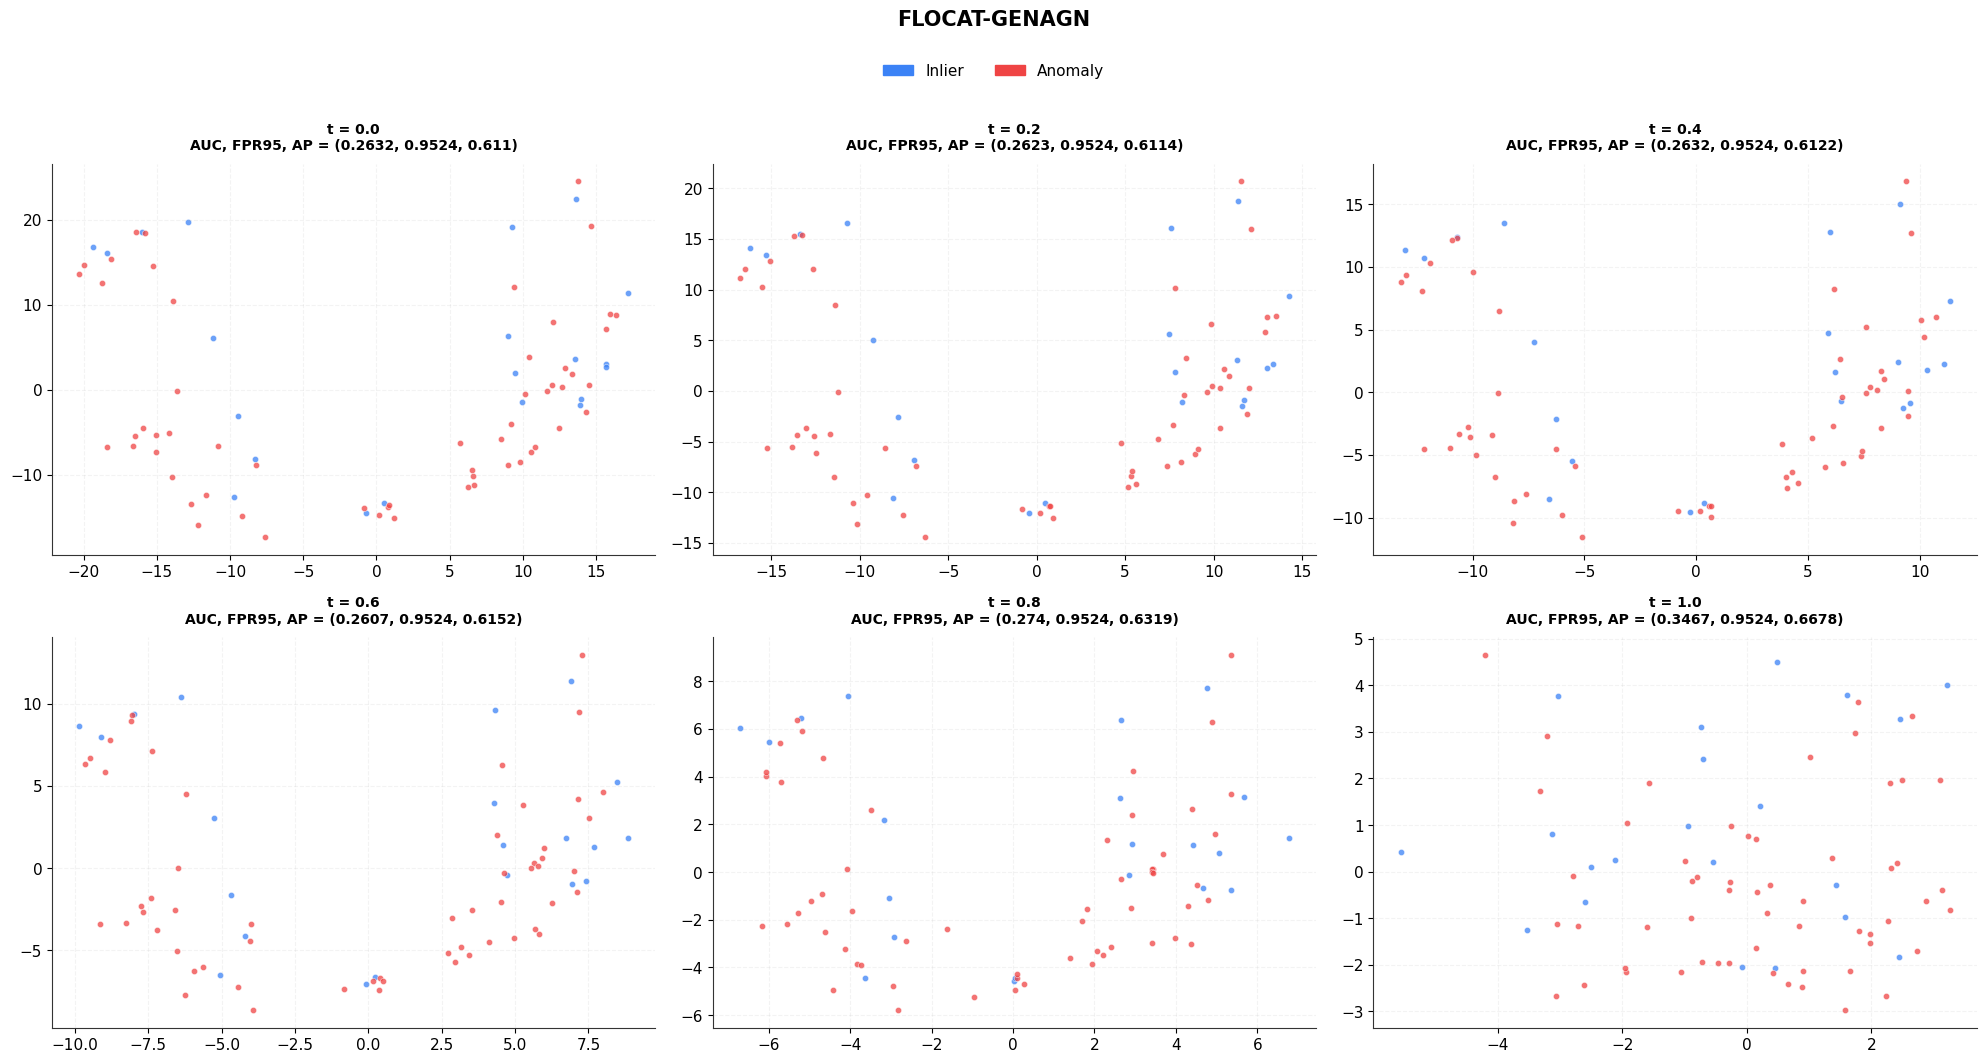

In [94]:
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.edgecolor': '#333333',
    'axes.linewidth': 0.8,
})

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.patch.set_facecolor('white')
axes = axes.flatten()
steps = torch.linspace(0, 1, n_steps)

color_map = {0: '#3B82F6', 1: '#EF4444'}  
label_map = {0: 'Inlier', 1: 'Anomaly'}
y_test_arr = np.array(y_test)

for i in range(6):
    X_i = all_x_inter[i].detach().cpu().numpy()

    pca = PCA(n_components=2)
    X_i_pca = pca.fit_transform(X_i)

    ax = axes[i]

    for cls, color in color_map.items():
        mask = y_test_arr == cls
        ax.scatter(
            X_i_pca[mask, 0],
            X_i_pca[mask, 1],
            c=color,
            label=label_map[cls],
            alpha=0.75,
            s=20,
            edgecolors='white',
            linewidths=0.4,
        )

    ax.set_title(
        f"t = {steps[i]:.1f}\n"
        f"AUC, FPR95, AP = {metrics_inter[i]}",
        fontsize=10,
        fontweight='bold',
        pad=10
    )

    ax.grid(alpha=0.15, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

handles = [mpatches.Patch(color=c, label=label_map[k]) for k, c in color_map.items()]
fig.legend(handles=handles, loc='upper center', ncol=2, frameon=False,
           bbox_to_anchor=(0.5, 1.02), fontsize=11)

fig.suptitle("FLOCAT-GENAGN",
             fontsize=15, fontweight='bold', y=1.06)

plt.tight_layout(w_pad=1)
plt.show()

# Time Series